# Notebook 03 — Drug Feature Extraction

**PharmaLens: An Explainable AI Framework for Drug–Target Interaction Prediction**

---

## Objective

This notebook extracts numerical representations from drug SMILES strings, transforming chemical structures into formats that machine learning models can process.

We generate three types of drug features:

1. **Molecular Descriptors** — Physicochemical properties (molecular weight, LogP, etc.)
2. **Morgan Fingerprints** — Binary vectors encoding circular substructure patterns
3. **Molecular Graphs** — Atoms as nodes, bonds as edges (for GNN models)

**Why multiple representations?** Different models benefit from different input types. Tree-based models (RF, XGBoost) work well with descriptors + fingerprints. CNN models (DeepDTA) use raw SMILES sequences. GNN models operate on molecular graphs. Comparing these representations is part of our research.

## Setup

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.utils.config import (
    PROCESSED_DATA_DIR, FIGURES_DIR, ensure_dirs, set_seed, set_plot_style
)
from src.features.drug_features import (
    compute_molecular_descriptors, compute_descriptors_batch,
    compute_morgan_fingerprint, compute_fingerprints_batch,
    compute_maccs_keys, encode_smiles, encode_smiles_batch,
    get_drug_feature_vector, DESCRIPTOR_NAMES, get_feature_names,
)
from src.features.mol_graph import smiles_to_graph, visualize_molecular_graph

set_seed(42)
COLORS = set_plot_style()
ensure_dirs()
print("Setup complete ✓")

Setup complete ✓


## 1. Load Cleaned Data

In [2]:
df = pd.read_csv(PROCESSED_DATA_DIR / 'kiba_clean.csv')
print(f"Loaded {len(df):,} interactions")
print(f"Unique drugs: {df['drug_id'].nunique()}")

# Get unique drugs for feature extraction
unique_drugs = df.drop_duplicates('drug_id')[['drug_id', 'smiles']].reset_index(drop=True)
print(f"\nUnique drug SMILES to process: {len(unique_drugs)}")
unique_drugs.head()

Loaded 118,254 interactions
Unique drugs: 2111

Unique drug SMILES to process: 2111


,drug_id,smiles
0,CHEMBL1087421,COc1cc2c(cc1Cl)C(c1ccc(Cl)c(Cl)c1)=NCC2
1,CHEMBL1088633,COc1cc2c(cc1Cl)C(c1cccc(Cl)c1)=NCC2
2,CHEMBL1090360,O=C(Cc1ccccc1)Nc1cccc(-c2nc3sccn3c2-c2ccnc(Nc3...
3,CHEMBL1688215,Nc1nccc(-c2ccc3c(N)n[nH]c3c2)n1
4,CHEMBL1765781,CNc1cncc(-c2c[nH]c(=O)c(NC(=O)c3ccc(N4CCCC4CN4...


## 2. Molecular Descriptors

**Molecular descriptors** are numerical values that describe physicochemical properties of a molecule. These are interpretable features that capture drug-likeness and chemical behavior.

| Descriptor | What it measures |
|------------|------------------|
| Molecular Weight | Size of the molecule (Daltons) |
| Heavy Atom Count | Number of non-hydrogen atoms |
| Ring Count | Number of ring structures |
| HBD / HBA | Hydrogen bond donors / acceptors |
| Rotatable Bonds | Molecular flexibility |
| TPSA | Topological Polar Surface Area — polarity |
| LogP | Lipophilicity (fat solubility) |
| Aromatic Rings | Flat ring structures |
| Fraction CSP3 | Carbon saturation — 3D complexity |

In [3]:
# Compute descriptors for all unique drugs
desc_df = compute_descriptors_batch(unique_drugs['smiles'].tolist())
desc_df['drug_id'] = unique_drugs['drug_id'].values

print(f"Descriptor matrix shape: {desc_df.shape}")
print(f"Columns: {list(desc_df.columns)}")
desc_df.head()

Computing descriptors: 100%|██████████| 2111/2111 [00:01<00:00, 1510.82it/s]

Descriptor matrix shape: (2111, 12)
Columns: ['molecular_weight', 'heavy_atom_count', 'ring_count', 'hbd', 'hba', 'rotatable_bonds', 'tpsa', 'logp', 'num_aromatic_rings', 'fraction_csp3', 'smiles', 'drug_id']


,molecular_weight,heavy_atom_count,ring_count,hbd,hba,rotatable_bonds,tpsa,logp,num_aromatic_rings,fraction_csp3,smiles,drug_id
0,340.64,21,3,0,2,2,21.59,5.05,2,0.1875,COc1cc2c(cc1Cl)C(c1ccc(Cl)c(Cl)c1)=NCC2,CHEMBL1087421
1,306.19,20,3,0,2,2,21.59,4.40,2,0.1875,COc1cc2c(cc1Cl)C(c1cccc(Cl)c1)=NCC2,CHEMBL1088633
2,587.71,43,7,2,8,8,96.68,6.28,6,0.1515,O=C(Cc1ccccc1)Nc1cccc(-c2nc3sccn3c2-c2ccnc(Nc3...,CHEMBL1090360
3,226.24,17,3,3,5,1,106.50,1.18,3,0.0000,Nc1nccc(-c2ccc3c(N)n[nH]c3c2)n1,CHEMBL1688215
4,473.58,35,5,3,7,7,106.25,3.19,3,0.3846,CNc1cncc(-c2c[nH]c(=O)c(NC(=O)c3ccc(N4CCCC4CN4...,CHEMBL1765781


In [4]:
# Descriptor statistics
print("Molecular Descriptor Statistics:")
print(desc_df[DESCRIPTOR_NAMES].describe().round(2).to_string())

Molecular Descriptor Statistics:
       molecular_weight  heavy_atom_count  ring_count      hbd      hba  rotatable_bonds     tpsa     logp  num_aromatic_rings  fraction_csp3
count           2111.00            2111.0     2111.00  2111.00  2111.00          2111.00  2111.00  2111.00              2111.0        2111.00
mean             401.90              28.8        4.14     2.61     5.48             4.49    98.45     3.47                 3.4           0.21
std              157.86              11.3        1.69     2.87     4.14             3.67    78.19     1.78                 1.2           0.15
min              150.18              10.0        0.00     0.00     0.00             0.00     8.81   -10.87                 0.0           0.00
25%              316.85              23.0        3.00     1.00     4.00             2.00    67.59     2.57                 3.0           0.08
50%              377.35              27.0        4.00     2.00     5.00             4.00    86.72     3.57         

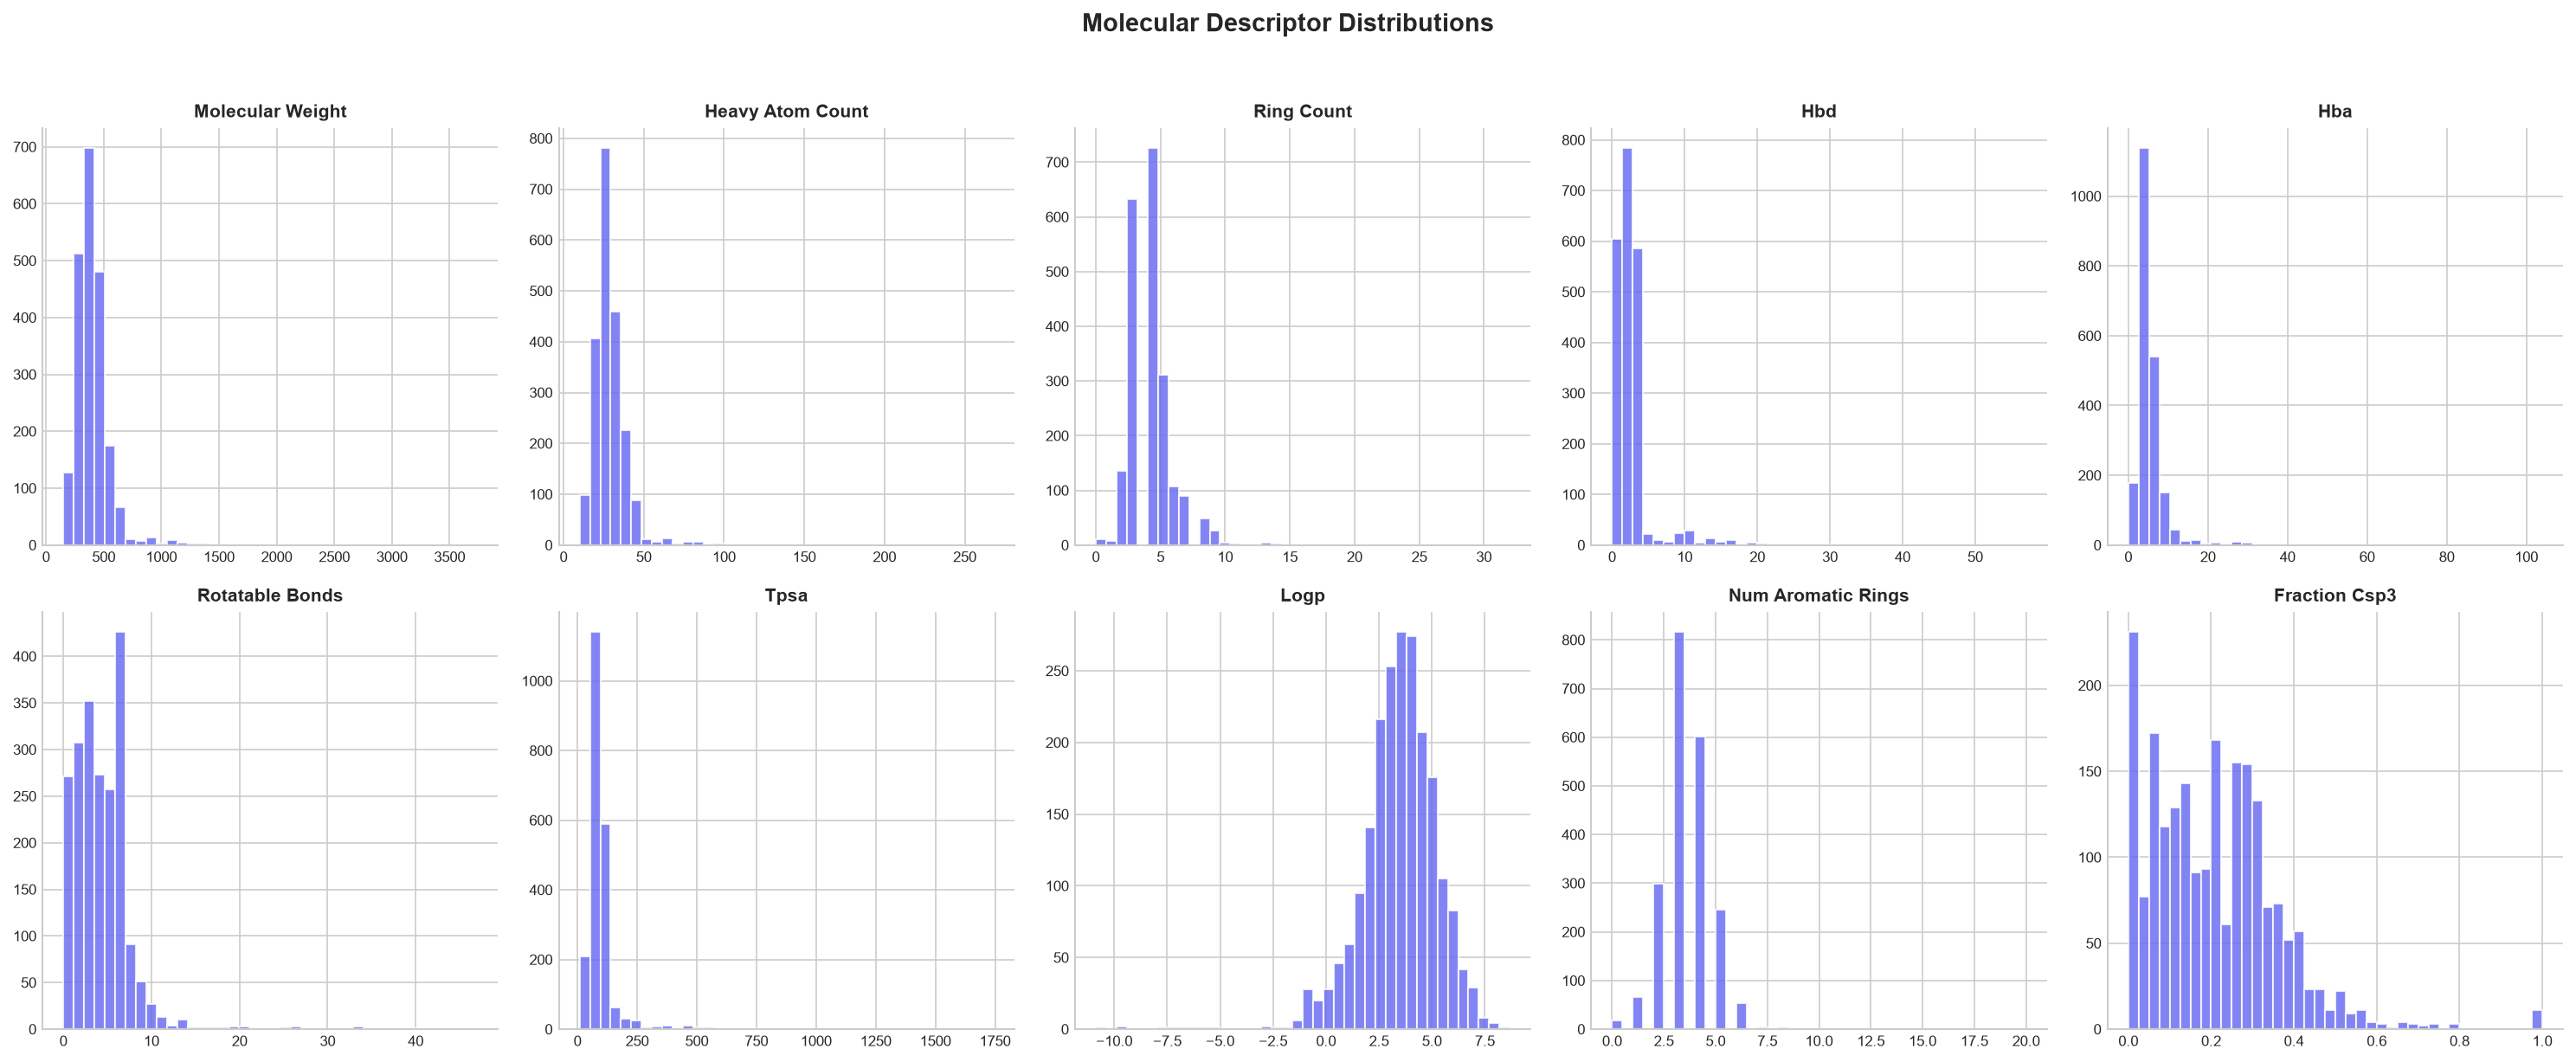

In [5]:
# Visualize descriptor distributions
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, name in enumerate(DESCRIPTOR_NAMES):
    axes[i].hist(desc_df[name].dropna(), bins=40, color=COLORS['primary'], alpha=0.8, edgecolor='white')
    axes[i].set_title(name.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    axes[i].tick_params(labelsize=8)

plt.suptitle('Molecular Descriptor Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'drug_descriptor_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

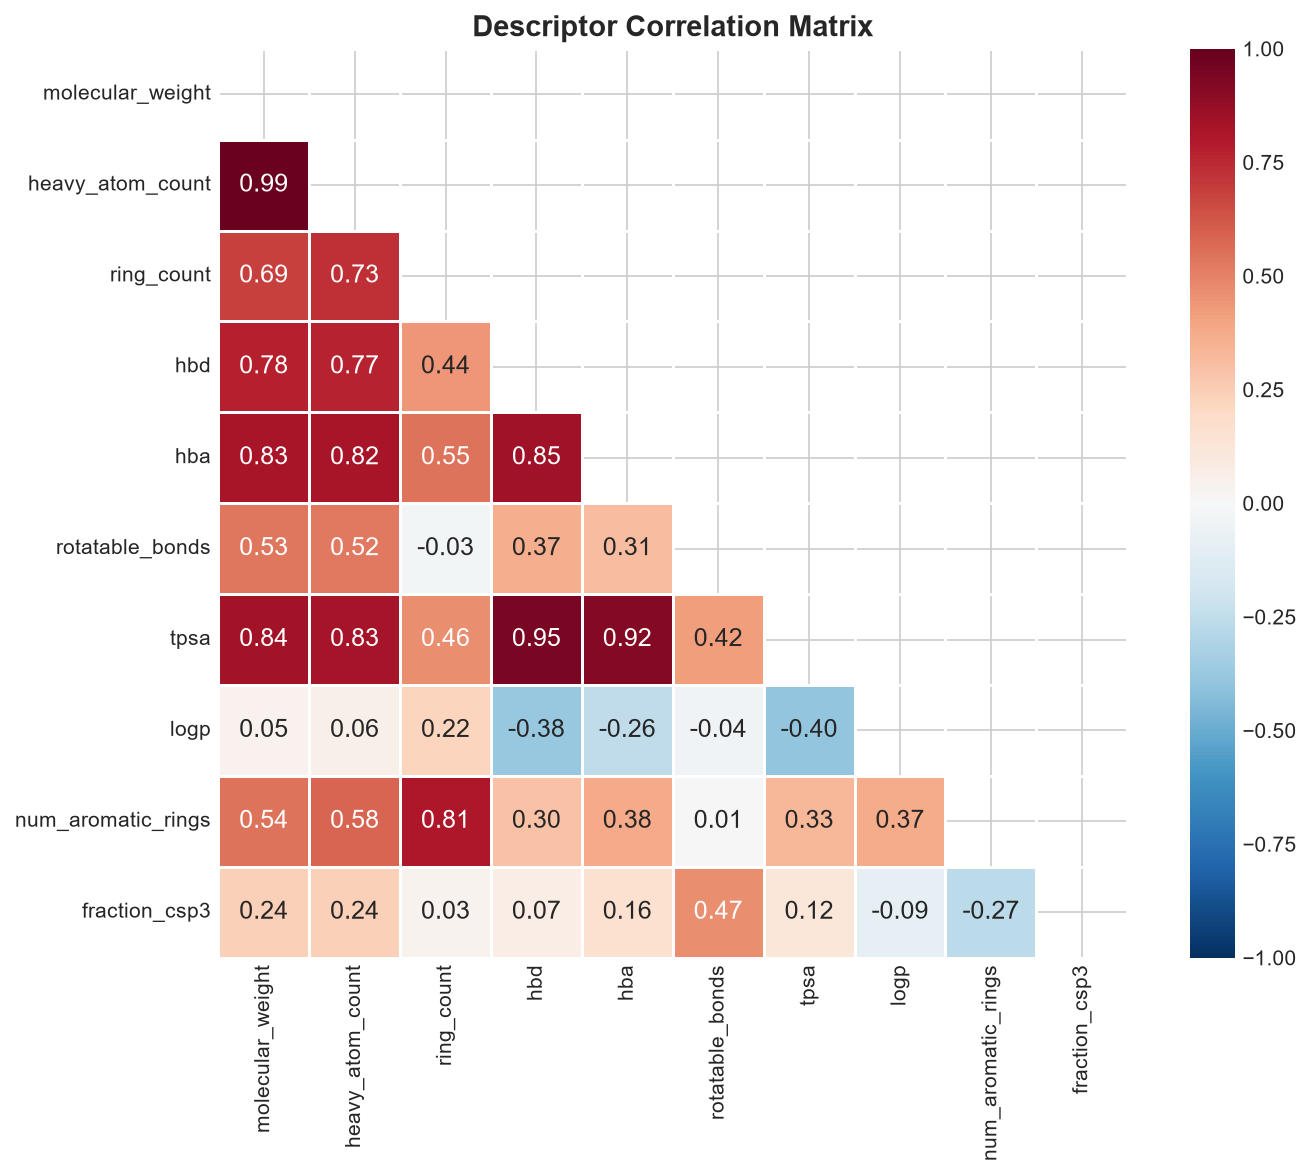

In [6]:
# Descriptor correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr = desc_df[DESCRIPTOR_NAMES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, square=True, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Descriptor Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'drug_descriptor_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Morgan Fingerprints

**Morgan fingerprints** (also called circular fingerprints or ECFP) encode the local chemical environment around each atom. A radius-2 Morgan fingerprint (ECFP4) captures substructure patterns within 2 bonds of each atom.

The result is a binary vector of fixed length (1024 bits) where each bit indicates the presence or absence of a particular substructure pattern.

Computing fingerprints:   0%|          | 1/2111 [00:00<15:44,  2.23it/s][19:04:52] DEPRECATION WARNING: please use MorganGenerator
[19:04:52] DEPRECATION WARNING: please use MorganGenerator
[19:04:52] DEPRECATION WARNING: please use MorganGenerator
[19:04:52] DEPRECATION WARNING: please use MorganGenerator
[19:04:52] DEPRECATION WARNING: please use MorganGenerator
[19:04:52] DEPRECATION WARNING: please use MorganGenerator
[19:04:52] DEPRECATION WARNING: please use MorganGenerator
[19:04:52] DEPRECATION WARNING: please use MorganGenerator
[19:04:52] DEPRECATION WARNING: please use MorganGenerator
[19:04:52] DEPRECATION WARNING: please use MorganGenerator
[19:04:52] DEPRECATION WARNING: please use MorganGenerator
[19:04:52] DEPRECATION WARNING: please use MorganGenerator
[19:04:52] DEPRECATION WARNING: please use MorganGenerator
[19:04:52] DEPRECATION WARNING: please use MorganGenerator
[19:04:52] DEPRECATION WARNING: please use MorganGenerator
[19:04:52] DEPRECATION WARNING: please use 

Fingerprint matrix shape: (2111, 1024)
Sparsity: 95.2% zeros
Average bits ON per molecule: 49.4


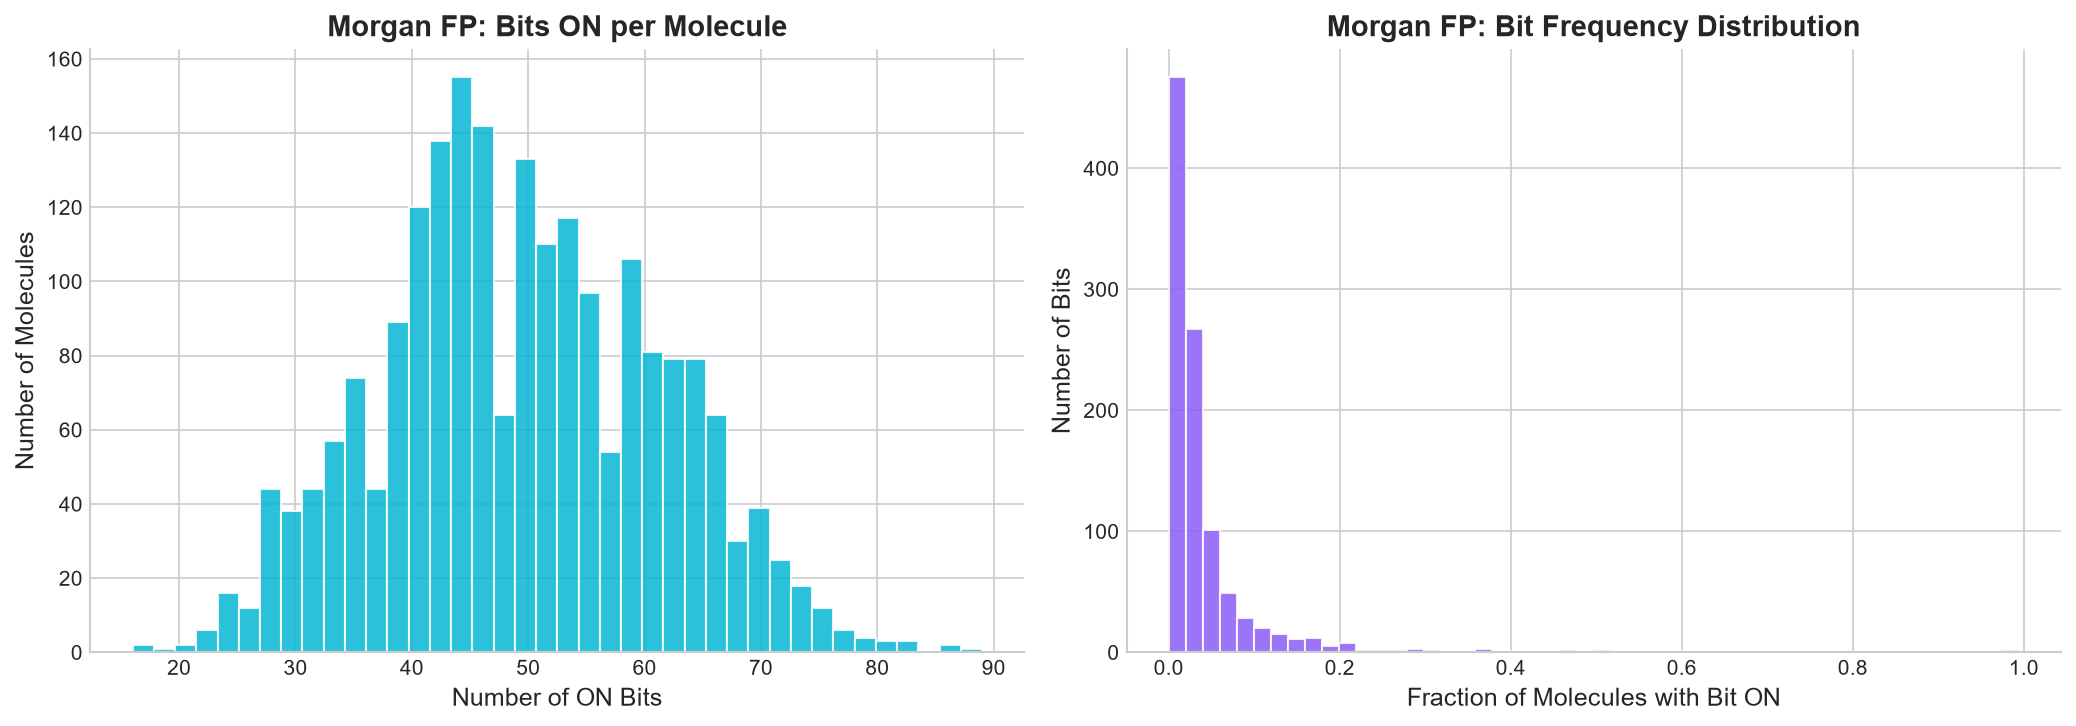

In [7]:
# Compute Morgan fingerprints
fps = compute_fingerprints_batch(unique_drugs['smiles'].tolist(), radius=2, n_bits=1024)
print(f"Fingerprint matrix shape: {fps.shape}")
print(f"Sparsity: {(fps == 0).mean() * 100:.1f}% zeros")
print(f"Average bits ON per molecule: {fps.sum(axis=1).mean():.1f}")

# Visualize fingerprint density
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bits ON per molecule
bits_on = fps.sum(axis=1)
axes[0].hist(bits_on, bins=40, color=COLORS['accent'], alpha=0.85, edgecolor='white')
axes[0].set_xlabel('Number of ON Bits')
axes[0].set_ylabel('Number of Molecules')
axes[0].set_title('Morgan FP: Bits ON per Molecule', fontweight='bold')

# Bit frequency across molecules
bit_freq = fps.mean(axis=0)
axes[1].hist(bit_freq[bit_freq > 0], bins=50, color=COLORS['secondary'], alpha=0.85, edgecolor='white')
axes[1].set_xlabel('Fraction of Molecules with Bit ON')
axes[1].set_ylabel('Number of Bits')
axes[1].set_title('Morgan FP: Bit Frequency Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'drug_fingerprint_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Molecular Graph Example

For **Graph Neural Network** models, we represent molecules as graphs:
- **Atoms → Nodes** (with features: atom type, degree, charge, hybridization, etc.)
- **Chemical bonds → Edges** (with features: bond type, conjugated, in ring)

Let's visualize an example molecule and its graph representation.

Drug ID: CHEMBL1087421
SMILES: COc1cc2c(cc1Cl)C(c1ccc(Cl)c(Cl)c1)=NCC2


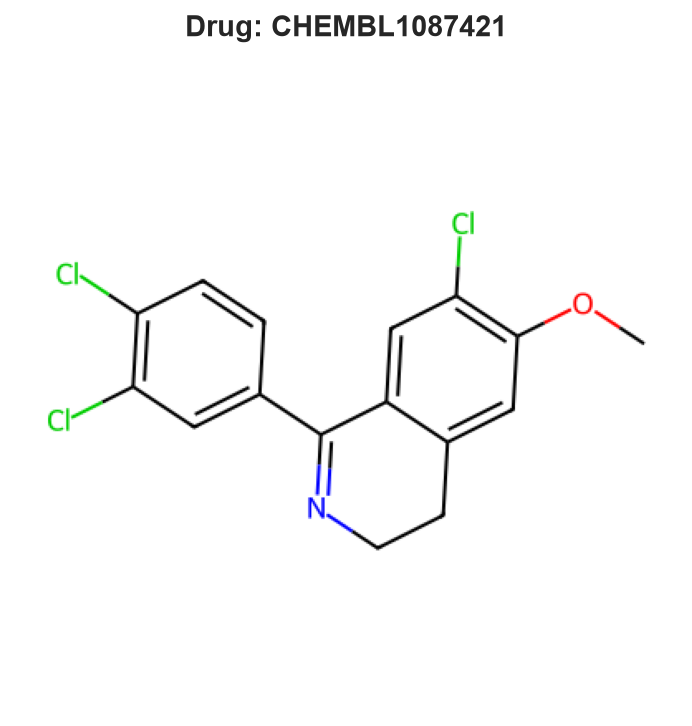

In [8]:
# Pick an example molecule
example_smiles = unique_drugs['smiles'].iloc[0]
example_drug_id = unique_drugs['drug_id'].iloc[0]

print(f"Drug ID: {example_drug_id}")
print(f"SMILES: {example_smiles}")

# Visualize 2D structure
img = visualize_molecular_graph(example_smiles, save_path=str(FIGURES_DIR / 'example_molecule.png'))
if img:
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'Drug: {example_drug_id}', fontweight='bold')
    plt.tight_layout()
    plt.show()

In [9]:
# Convert to graph and inspect
graph = smiles_to_graph(example_smiles)

print(f"\nGraph representation:")
print(f"  Number of atoms (nodes): {graph['num_atoms']}")
print(f"  Number of bonds (original): {graph['num_bonds']}")
print(f"  Edge index shape: {graph['edge_index'].shape} (undirected: 2 × num_bonds × 2)")
print(f"  Node feature shape: {graph['node_features'].shape}")
print(f"  Edge feature shape: {graph['edge_features'].shape}")

print(f"\nFirst 3 atom features (node features):")
print(graph['node_features'][:3].round(2))

print(f"\nFirst 4 edges (connections):")
for e in range(min(4, graph['edge_index'].shape[1])):
    i, j = graph['edge_index'][:, e]
    print(f"  Atom {i} ↔ Atom {j}  (features: {graph['edge_features'][e].tolist()})")


Graph representation:
  Number of atoms (nodes): 21
  Number of bonds (original): 23
  Edge index shape: (2, 46) (undirected: 2 × num_bonds × 2)
  Node feature shape: (21, 30)
  Edge feature shape: (46, 6)

First 3 atom features (node features):
[[1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  1.   0.   0.   0.   0.   0.   3.   0.   0.   1.   0.   0.   0.   0.
  0.   0.06]
 [0.   0.   1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   1.   0.   0.   0.   0.   0.   0.   1.   0.   0.   0.   0.   0.
  0.   0.08]
 [1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   1.   0.   0.   0.   0.   0.   1.   0.   0.   0.   0.   1.
  1.   0.06]]

First 4 edges (connections):
  Atom 0 ↔ Atom 1  (features: [1.0, 0.0, 0.0, 0.0, 0.0, 0.0])
  Atom 1 ↔ Atom 0  (features: [1.0, 0.0, 0.0, 0.0, 0.0, 0.0])
  Atom 1 ↔ Atom 2  (features: [1.0, 0.0, 0.0, 0.0, 1.0, 0.0])
  Atom 2 ↔ Atom 1  (features: [1.0, 0.0, 0.0, 0.0, 1.0, 0.0])


## 5. SMILES Encoding (for DeepDTA)

The **DeepDTA model** processes SMILES strings as 1D sequences using character-level encoding. Each character is mapped to an integer, and the sequence is padded/truncated to a fixed length.

In [10]:
# Encode SMILES for DeepDTA
encoded = encode_smiles(example_smiles, max_length=100)
print(f"Original SMILES: {example_smiles[:60]}...")
print(f"Encoded (first 30): {encoded[:30]}")
print(f"Encoded shape: {encoded.shape}")
print(f"Non-zero positions: {np.sum(encoded > 0)} / {len(encoded)}")

# Batch encoding
all_encoded_smiles = encode_smiles_batch(unique_drugs['smiles'].tolist(), max_length=100)
print(f"\nBatch encoded shape: {all_encoded_smiles.shape}")
print(f"Max SMILES length used: {(all_encoded_smiles > 0).sum(axis=1).max()}")

Original SMILES: COc1cc2c(cc1Cl)C(c1ccc(Cl)c(Cl)c1)=NCC2...
Encoded (first 30): [23 32 47 10 47 47 11 47  3 47 47 10 23 54  4 23  3 47 10 47 47 47  3 23
 54  4 47  3 23 54]
Encoded shape: (100,)
Non-zero positions: 39 / 100

Batch encoded shape: (2111, 100)
Max SMILES length used: 100


## 6. Combined Feature Vector (for RF/XGBoost)

For tree-based models, we concatenate molecular descriptors and Morgan fingerprints into a single feature vector per drug.

In [11]:
# Compute combined feature vectors for all drugs
from tqdm import tqdm
import pickle

drug_feature_dict = {}
failed = []

for _, row in tqdm(unique_drugs.iterrows(), total=len(unique_drugs), desc='Computing drug features'):
    fv = get_drug_feature_vector(row['smiles'])
    if fv is not None:
        drug_feature_dict[row['drug_id']] = fv
    else:
        failed.append(row['drug_id'])

print(f"\nSuccessfully computed features for {len(drug_feature_dict)} drugs")
print(f"Failed: {len(failed)} drugs")

# Feature vector size
sample_fv = next(iter(drug_feature_dict.values()))
feature_names = get_feature_names()
print(f"Feature vector size: {len(sample_fv)} ({len(DESCRIPTOR_NAMES)} descriptors + 1024 fingerprint bits)")

Computing drug features:   0%|          | 0/2111 [00:00<?, ?it/s][19:05:09] DEPRECATION WARNING: please use MorganGenerator
[19:05:09] DEPRECATION WARNING: please use MorganGenerator
[19:05:09] DEPRECATION WARNING: please use MorganGenerator
[19:05:09] DEPRECATION WARNING: please use MorganGenerator
[19:05:09] DEPRECATION WARNING: please use MorganGenerator
[19:05:09] DEPRECATION WARNING: please use MorganGenerator
[19:05:09] DEPRECATION WARNING: please use MorganGenerator
[19:05:09] DEPRECATION WARNING: please use MorganGenerator
[19:05:09] DEPRECATION WARNING: please use MorganGenerator
[19:05:09] DEPRECATION WARNING: please use MorganGenerator
[19:05:09] DEPRECATION WARNING: please use MorganGenerator
[19:05:09] DEPRECATION WARNING: please use MorganGenerator
[19:05:09] DEPRECATION WARNING: please use MorganGenerator
[19:05:09] DEPRECATION WARNING: please use MorganGenerator
[19:05:09] DEPRECATION WARNING: please use MorganGenerator
[19:05:09] DEPRECATION WARNING: please use MorganG


Successfully computed features for 2111 drugs
Failed: 0 drugs
Feature vector size: 1034 (10 descriptors + 1024 fingerprint bits)


In [12]:
# Save computed features
with open(PROCESSED_DATA_DIR / 'drug_features.pkl', 'wb') as f:
    pickle.dump(drug_feature_dict, f)
print(f"Drug features saved: {PROCESSED_DATA_DIR / 'drug_features.pkl'}")

# Save descriptors table
desc_df.to_csv(PROCESSED_DATA_DIR / 'drug_descriptors.csv', index=False)
print(f"Descriptor table saved: {PROCESSED_DATA_DIR / 'drug_descriptors.csv'}")

# Save encoded SMILES
np.save(PROCESSED_DATA_DIR / 'drug_smiles_encoded.npy', all_encoded_smiles)
print(f"Encoded SMILES saved: {PROCESSED_DATA_DIR / 'drug_smiles_encoded.npy'}")

Drug features saved: C:\Users\ASUS\Documents\projects\Pharmalens\data\processed\drug_features.pkl
Descriptor table saved: C:\Users\ASUS\Documents\projects\Pharmalens\data\processed\drug_descriptors.csv
Encoded SMILES saved: C:\Users\ASUS\Documents\projects\Pharmalens\data\processed\drug_smiles_encoded.npy


## Observations

1. **Descriptors** provide interpretable physicochemical properties. Correlations between descriptors (e.g., molecular weight and heavy atom count) are expected — they measure related properties.

2. **Morgan fingerprints** are sparse (most bits are 0). This is normal — each bit represents a specific substructure, and most molecules contain only a fraction of all possible substructures.

3. **Molecular graphs** preserve the full structural information, allowing GNNs to learn directly from the chemical topology.

4. **SMILES encoding** converts the text representation into fixed-length integer sequences suitable for 1D CNN processing (DeepDTA approach).

## Conclusion

Four drug representations have been generated:
- Molecular descriptors (10D) — saved as CSV
- Morgan fingerprints (1024D) — included in combined feature vectors
- Combined feature vectors (1034D) — saved as pickle for RF/XGBoost
- SMILES integer encoding (100D) — saved as NumPy array for DeepDTA
- Molecular graph conversion function ready for GNN training

**Next:** [Notebook 04 — Protein Features](./04_protein_features.ipynb)